In [65]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [40]:
data_path = Path.home() / "Documents" / "data-science-course"
df=pd.read_csv(data_path / "Advertising.csv")
print(df.head())

   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [41]:
x=df['TV']
y=df['sales']

In [42]:
def knn_model(x_train, y_train, k, x_grid):
    y_pred=[]
    for x in x_grid:
        distance= np.abs(x_train - x)
        nearests= np.argsort(distance)[:k]
        y_pred.append(np.mean(y_train.iloc[nearests]))
    return np.array(y_pred)

In [43]:
order = np.argsort(x)
x=x[order]
y=y[order]
x_grid=np.linspace(min(x), max(x), len(x))

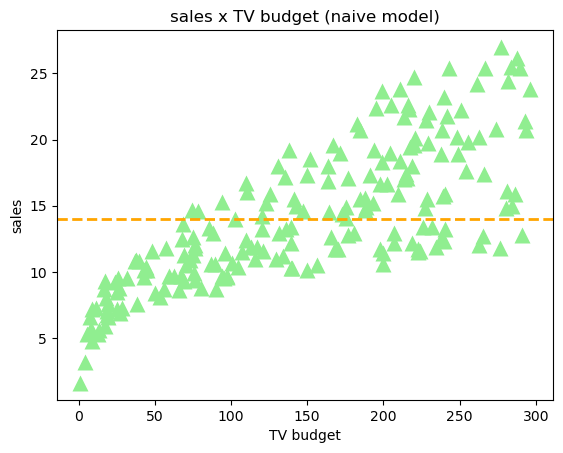

In [44]:
y_naive=y.mean()

plt.plot(x, y, marker= '^',linestyle= 'none', markersize= '12', markeredgecolor='none', markerfacecolor= 'lightgreen')
plt.axhline(y_naive, color='orange', linestyle='--', linewidth='2')
plt.title('sales x TV budget (naive model)')
plt.xlabel('TV budget')
plt.ylabel('sales')
plt.show()  

[]

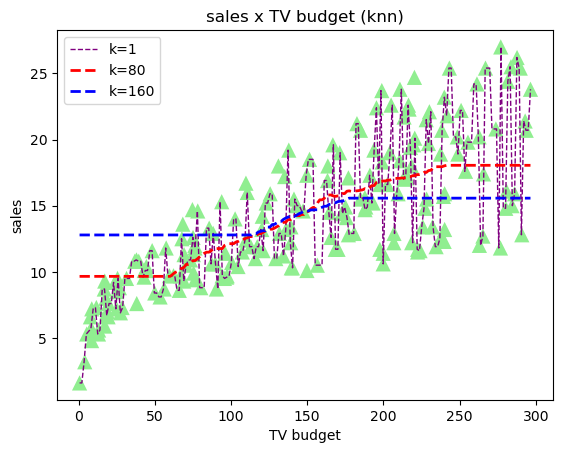

In [45]:
k_values=[1, 80, 160]
pred = {k: knn_model(x,y,k, x_grid) for k in k_values}
colors= ['purple','red', 'blue']
lines=[1,2,2]
plt.scatter(x, y, marker='^', color='lightgreen', edgecolor='none', s=120)
for color, line, (i, y_hat) in zip(colors,lines, pred.items()):
    plt.plot(x_grid, y_hat, color= color, linestyle='--', label= f'k={i}', linewidth=line)
plt.title('sales x TV budget (knn)')
plt.ylabel('sales')
plt.xlabel('TV budget')
plt.legend()
plt.plot()


In [46]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.20, random_state=42)
k_values=[_ for _ in range(1,10)]
y_pred={k: knn_model(x_train, y_train, k, x_test) for k in k_values}
mse_model={}
r2={}
y_mean_test=np.mean(y_test)
mse_media=(sum((y_test - y_mean_test) **2))/len(y_test)
for k, yz in y_pred.items():
    sumerror=0
    for i in range(len(y_test)):
        sumerror+=((y_test.iloc[i]-yz[i])**2)
    mse_model[k]=sumerror/len(y_test)
    r2[k]=1-(mse_model[k]/mse_media)

mse_model=dict(sorted(mse_model.items()))
r2=dict(sorted(r2.items()))
print(mse_media)
print(mse_model)
print(r2)
print(max(r2.values()))


18.50234375
{1: np.float64(17.303500000000007), 2: np.float64(16.21725), 3: np.float64(12.406055555555557), 4: np.float64(12.443296874999996), 5: np.float64(13.386219999999998), 6: np.float64(13.700638888888895), 7: np.float64(13.735418367346941), 8: np.float64(12.909027343750001), 9: np.float64(12.740231481481484)}
{1: np.float64(0.06479415614575823), 2: np.float64(0.12350293459443484), 3: np.float64(0.32948734910648514), 4: np.float64(0.32747455981083506), 5: np.float64(0.2765121986234854), 6: np.float64(0.2595187358958838), 7: np.float64(0.2576390022292748), 8: np.float64(0.3023031288265845), 9: np.float64(0.3114260737112571)}
0.32948734910648514


// MSE for every knn_model calculated //

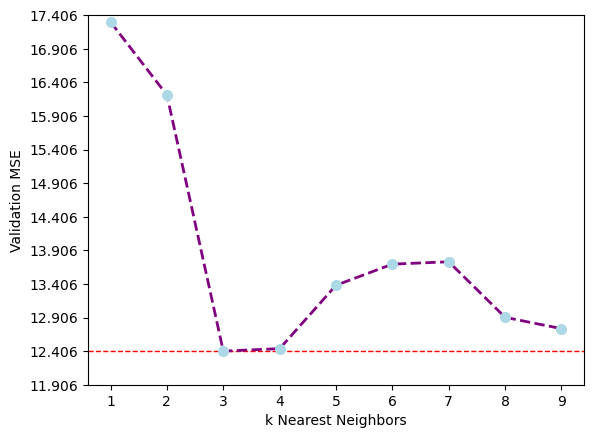

In [47]:
ymin=min(mse_model.values())
ymax=max(mse_model.values())
plt.axhline(ymin, linestyle='--', color='red', marker='none', linewidth=1)
plt.plot(list(mse_model.keys()), list(mse_model.values()), marker='o', linestyle='--', markerfacecolor='lightblue', markeredgecolor='none', color='purple', markersize='8', linewidth=2)
plt.xlabel('k Nearest Neighbors')
plt.ylabel('Validation MSE')
plt.ylim((ymin, ymax))
plt.yticks(np.arange(ymin-0.5, ymax+0.5, 0.5))
plt.show()

// plot all the Knn_models calculated // 

// Linear Regression //

In [ ]:
def fit_and_plot(df_s, test_s=0.2):
    x=df_s[:, :-1]
    y=df_s[:, -1]
    x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=test_s, random_stat=42)
    model = LinearRegression()

    model.fit(x_train,y_train)
    y_pred_train=model.predict(x_train)
    y_pred_test=model.predict(x_test)

    plt.scatter(x_train, y_train, marker='o', s=40, color='lightblue', label='Train data')
    plt.scatter(x_test,y_test, marker='o', color='lightred', s=40, label= 'Test data')
    plt.plot(x_train, y_pred_train, linestyle='-.', color='purple', linewidth=1.5)
    plt.plt(x_test, y_pred_test, linestyle='.', color='red', linewidth=1.5)
    plt.legend()
    plt.show()

    r2_train= r2_score(y_train, y_pred_train)
    r2_test= r2_score(y_test,y_pred_test)


    return r2_train, r2_test 



In [ ]:
reg=LinearRegression()
y_name='Sales'
df_names=[i for i in df.columns if i != y_name]
df_models=pd.DataFrame(columns=['Predictor', 'R2_Train', 'R2_Test'])
for name in df_names:
    r2_train, r2_test= fit_and
#print(f'Slope (b0): {reg_linear.coef_}')
#print(f'Intercept (b1): {reg_linear.intercept_}')

,Predictor,R2_Train,R2_Test
